In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_blobs, make_circles

x, y = make_circles(noise=.25, factor=.5, random_state=1)

# we rename the classes 'blue' and 'red' for illustration purposes
y_named = np.array(['blue', 'red'])[y]

# we can tell train_test_split with arbitarily many arrays;
# all will be split in a consistent manner
x_train, x_test, y_train_named, y_test_named, y_train, y_test = \
    train_test_split(x, y_named, y, random_state=0)

# build the gradient boosting model
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(x_train, y_train_named)

GradientBoostingClassifier(random_state=0)

In [3]:
print('x_test.shape: {}'.format(x_test.shape))
print('Decision function shape: {}'.format(
    gbrt.decision_function(x_test).shape))

x_test.shape: (25, 2)
Decision function shape: (25,)


In [4]:
# show the first new entries of decision_function
print('Decision function:\n{}'.format(gbrt.decision_function(x_test)[:6]))

Decision function:
[ 4.13592603 -1.70169917 -3.95106099 -3.62609552  4.28986642  3.66166081]


In [5]:
print('Thresholded decision function: \n{}'.format(
    gbrt.decision_function(x_test) > 0))
print('Predictions:\n{}'.format(gbrt.predict(x_test)))

Thresholded decision function: 
[ True False False False  True  True False  True  True  True False  True
  True False  True False False False  True  True  True  True  True False
 False]
Predictions:
['red' 'blue' 'blue' 'blue' 'red' 'red' 'blue' 'red' 'red' 'red' 'blue'
 'red' 'red' 'blue' 'red' 'blue' 'blue' 'blue' 'red' 'red' 'red' 'red'
 'red' 'blue' 'blue']


In [5]:
# make the boolean True/False into 0 and 1
greater_zero = (gbrt.decision_function(x_test) > 0).astype(int)

# use 0 and 1 as indices into classes_
pred = gbrt.classes_[greater_zero]

# pred is the same as the output of gbrt.predict
print('Pred is equal to predictions: {}'.format(
    np.all(pred == gbrt.predict(x_test))))

Pred is equal to predictions: True


In [6]:
decision_function = gbrt.decision_function(x_test)
print('Decision function minimum {:.2f} maximum: {:.2f}'.format(
    np.min(decision_function), np.max(decision_function)))

Decision function minimum -7.69 maximum: 4.29


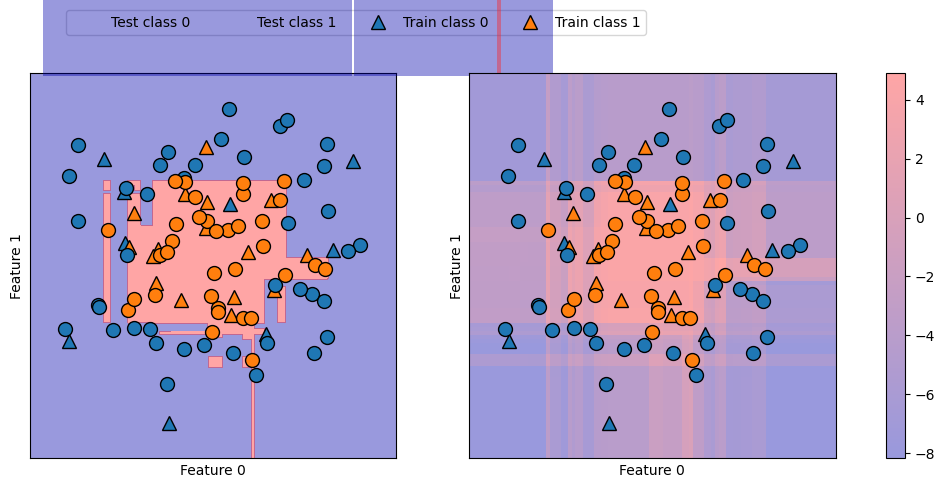

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mglearn.tools.plot_2d_separator(gbrt, x, ax=axes[0], alpha=.4,
                               fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(gbrt, x, ax=axes[1],
                                              alpha=.4, cm=mglearn.ReBl)

for ax in axes:
    # plot training and test points
    mglearn.discrete_scatter(x_test[:, 0], x_test[:, 1], y_test,
                            markers='^', ax=ax)
    mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train,
                            markers='o', ax=ax)
    ax.set_xlabel('Feature 0')
    ax.set_ylabel('Feature 1')
cbar = plt.colorbar(scores_image, ax=axes.tolist())
axes[0].legend(['Test class 0', 'Test class 1', 'Train class 0',
               'Train class 1'], ncol=4, loc=(.1, 1.1))


## Predicting Probabilities

In [14]:
print('Shape of probabilities: {}'.format(gbrt.predict_proba(x_test).shape))

Shape of probabilities: (25, 2)


In [15]:
# show the first few entries of predict_proba
print('Predicted probabilities:\n{}'.format(
    gbrt.predict_proba(x_test[:6])))

Predicted probabilities:
[[0.01573626 0.98426374]
 [0.84575653 0.15424347]
 [0.98112869 0.01887131]
 [0.97407033 0.02592967]
 [0.01352142 0.98647858]
 [0.02504637 0.97495363]]


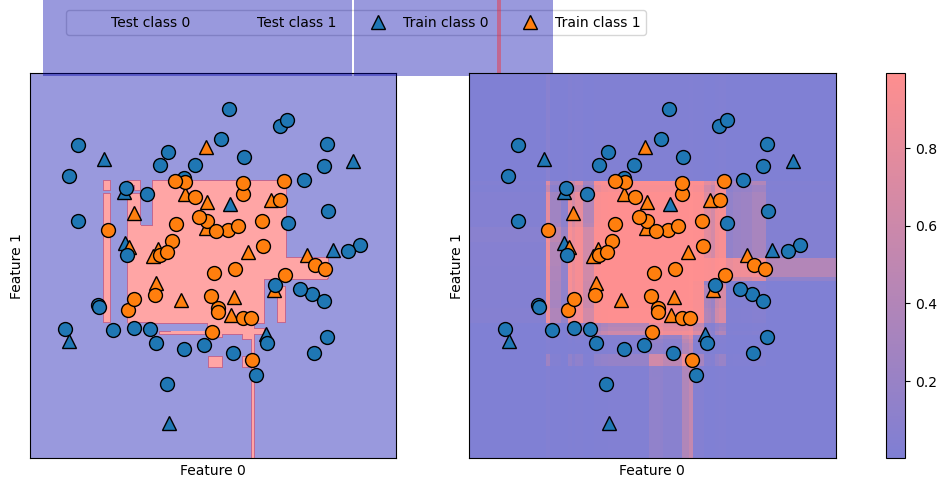

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mglearn.tools.plot_2d_separator(
    gbrt, x, ax=axes[0], alpha=.4, fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(
    gbrt, x, ax=axes[1], alpha=.5, cm=mglearn.ReBl, function='predict_proba')

for ax in axes:
    # plot training and test points
    mglearn.discrete_scatter(x_test[:, 0], x_test[:, 1], y_test,
                            markers='^', ax=ax)
    mglearn.discrete_scatter(x_train[:, 0], x_train[:, 1], y_train,
                            markers='o', ax=ax)
    ax.set_xlabel('Feature 0')
    ax.set_ylabel('Feature 1')
cbar = plt.colorbar(scores_image, ax=axes.tolist())
axes[0].legend(['Test class 0', 'Test class 1', 'Train class 0',
               'Train class 1'], ncol=4, loc=(.1, 1.1))


## Uncertainty in Multiclass Classification

In [6]:
from sklearn.datasets import load_iris

iris = load_iris()
x_train, x_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0)

gbrt = GradientBoostingClassifier(learning_rate=0.01, random_state=0)
gbrt.fit(x_train, y_train)

print('Decision function shape: {}'.format(gbrt.decision_function(x_test).shape))

# plot the first few entries of the decision function
print('Decision functio:\n{}'.format(gbrt.decision_function(x_test)[:6, :]))

Decision function shape: (38, 3)
Decision functio:
[[-1.94508029 -2.01517311  0.12762926]
 [-1.94762009  0.04959233 -1.86975822]
 [ 0.08367469 -2.01610565 -1.86744871]
 [-1.94508859 -2.01517311  0.12762926]
 [ 0.08367469 -2.01610565 -1.86744871]
 [-1.94508029 -2.01517311  0.12762926]]


In [7]:
print('Argmax of decision function:\n{}'.format(
    np.argmax(gbrt.decision_function(x_test), axis=1)))
print('Prediction:\n{}'.format(gbrt.predict(x_test)))

Argmax of decision function:
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Prediction:
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]


In [8]:
# show the first few entries of predict_proba
print('Predicted probabilities:\n{}'.format(gbrt.predict_proba(x_test)[:6]))

# show that sums across rows are one
print('Sums: {}'.format(gbrt.predict_proba(x_test)[:6].sum(axis=1)))

Predicted probabilities:
[[0.10122859 0.09437615 0.80439526]
 [0.10582615 0.77977861 0.11439524]
 [0.79076534 0.09685557 0.11237909]
 [0.10122783 0.09437623 0.80439594]
 [0.79076534 0.09685557 0.11237909]
 [0.10122859 0.09437615 0.80439526]]
Sums: [1. 1. 1. 1. 1. 1.]


In [11]:
print('Argmax of predicted probabilities:\n{}'.format(
    np.argmax(gbrt.predict_proba(x_test), axis=1)))
print('Predictions:\n{}'.format(gbrt.predict(x_test)))

Argmax of predicted probabilities:
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Predictions:
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]


In [14]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=10000)

# represent each target by its class name in the iris dataset
named_target = iris.target_names[y_train]
logreg.fit(x_train, named_target)
print('Unique classes in ttraining data: {}'.format(logreg.classes_))
print('Predictions: {}'.format(logreg.predict(x_test)[:10]))
argmax_dec_func = np.argmax(logreg.decision_function(x_test), axis=1)
print('argmax of decision function: {}'.format(argmax_dec_func[:10]))
print('argmax combined with classes_: {}'.format(
        logreg.classes_[argmax_dec_func][:10]))

Unique classes in ttraining data: ['setosa' 'versicolor' 'virginica']
Predictions: ['virginica' 'versicolor' 'setosa' 'virginica' 'setosa' 'virginica'
 'setosa' 'versicolor' 'versicolor' 'versicolor']
argmax of decision function: [2 1 0 2 0 2 0 1 1 1]
argmax combined with classes_: ['virginica' 'versicolor' 'setosa' 'virginica' 'setosa' 'virginica'
 'setosa' 'versicolor' 'versicolor' 'versicolor']
